# Pyomo.DAE: Racing Example Revisited
**Prepared by:** Prof. Alexander Dowling, Molly Dougher (mdoughe6@nd.edu, 2023)

In [1]:
# Install Pyomo and solvers for Google Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

# import Pyomo library
import pyomo.environ as pyo
import pyomo.dae as dae
import matplotlib.pyplot as plt
from pyomo.environ import units
from pyomo.util.check_units import assert_units_consistent

## Car Example

Adapted from https://github.com/Pyomo/pyomo/blob/master/examples/dae/car_example.py

You are a race car driver with a simple goal. Drive distance $L$ in the minimal amount of time **but** come to a complete stop at the finish line.

### Optimal Control Problem Formulation

Mathematically, you want to solve the following optimal control problem:

$$\begin{align*}
\min_{u} \quad & t_f \\
\mathrm{s.t.} \quad & \frac{dx}{dt} = v \\
& \frac{dv}{dt} = u - R v^2 \\
& x(t=0) = 0, ~~ x(t=t_f) = L \\
& v(t=0) = 0, ~~ v(t=t_f) = 0 \\
& -3 \leq u \leq 1
\end{align*}$$

where $u$ is the acceleration/braking (your control variable) and $R$ is the drag coefficient (parameter).

### Scale Time

Let $t = \tau \cdot t_f$ where $\tau \in [0,1]$. Thus $dt = t_f d\tau$. The optimal control problem becomes:

$$\begin{align*}
\min_{u} \quad & t_f \\
\mathrm{s.t.} \quad & \frac{dx}{d\tau} = t_f v \\
& \frac{dv}{d\tau} = t_f (u - R v^2) \\
& x(\tau = 0) = 0, ~~ x(\tau = 1) = L \\
& v(\tau = 0) = 0, ~~ v(\tau = 1) = 0 \\
& -3 \leq u \leq 1
\end{align*}$$

### Orthogonal Collocation on Finite Elements: Manual Approach

Here is the "classical"/"old school" way of manually implementing collocation on finite elements with sets.

**Indices and Sets**
* Finite elements: $i \in \mathcal{I} = \{1,2,...,N_{FE}\}$
* Finite elements (except first): $\mathcal{I} \setminus 1$
* Internal collocation points: $j,k \in \mathcal{J} = \{1,2,...,N_{C}\}$


**Parameters**
* Coefficients in collocation/Runge-Kutta formula: $a_{k,j}$
* Drag coefficient: $R$
* Race length: $L$
* Scaled time for each finite element: $h_i = \frac{1}{N_{FE}}$

**Variables**
* Position (internal collocation points): $x_{i,j}$
* Position (beginning of each finite element): $\bar{x}_{i}$
* Position derivative (internal collocation points): $\dot{x}_{i,j}$
* Velocity (internal collocation points): $v_{i,j}$
* Velocity (beginning of each finite element): $\bar{v}_{i}$
* Velocity derivative (internal collocation points): $\dot{v}_{i,j}$
* Time (internal collocation points): $t_{i,j}$
* Time (beginning of each finite element): $\bar{t}_{i}$
* Acceleration (control degrees of freedom): $u_i$

**Objective and Constraints**

$$\begin{align*}
\min \quad & t_f \\
\mathrm{s.t.} \quad & \mathrm{Differential~equation~for~x:} \\ 
& x_{i,j} = \bar{x}_{i} + h_i \sum_{k \in \mathcal{J}} a_{k,j} \dot{x}_{i,k},\quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\
& \bar{x}_{i} = \bar{x}_{i-1} + h_{i-1} \sum_{k \in \mathcal{J}} a_{k,N_C} \dot{x}_{i-1,k},\quad \forall i \in \mathcal{I} \setminus 1\\
& \dot{x}_{i,j} = t_f v_{i,j}, \quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\ \\
& \mathrm{Differential~equation~for~v:} \\ 
& v_{i,j} = \bar{v}_{i} + h_i \sum_{k \in \mathcal{J}} a_{k,j} \dot{v}_{i,k},\quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\
& \bar{v}_{i} = \bar{v}_{i-1} + h_{i-1} \sum_{k \in \mathcal{J}} a_{k,N_C} \dot{v}_{i-1,k},\quad \forall i \in \mathcal{I} \setminus 1\\
& \dot{v}_{i,j} = t_f (u_{i} - R v_{i,j}^2), \quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\ \\
& \mathrm{Differential~equation~for~time:} \\
& t_{i,j} = \bar{t}_{i} + h_i \sum_{k \in \mathcal{J}} a_{k,j} t_f,\quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\
& \bar{t}_{i} = \bar{t}_{i-1} + h_{i-1} \sum_{k \in \mathcal{J}} a_{k,N_C} t_f,\quad \forall i \in \mathcal{I} \setminus 1\\ \\
& \mathrm{Initial~conditions:} \\ 
& \bar{x}_{1} = 0, \quad \bar{v}_{1} = 0, \quad \bar{t}_1 = 0\\ \\
& \mathrm{Boundary~conditions:} \\ 
& L = \bar{x}_{N_{FE}} + h_{N_{FE}} \sum_{k \in \mathcal{J}} a_{k,N_C} \dot{x}_{N_{FE},k}, \\
& 0 = \bar{v}_{N_{FE}} + h_{N_{FE}} \sum_{k \in \mathcal{J}} a_{k,N_C} \dot{v}_{N_{FE},k}, \\ \\
& \mathrm{Bounds~on~acceleration:} \\
& -3 \leq u_i \leq 1, \quad \forall i \in \mathcal{I}
\end{align*}$$

In [2]:
# Define the model
m2 = pyo.ConcreteModel()

# Define model parameters.
#
# R multiplies v**2 to give an acceleration, so R has units of 1/length.
m2.R = pyo.Param(initialize=0.001, units=1 / units.m)  # Friction factor
m2.L = pyo.Param(initialize=100.0, units=units.m)  # Final position

# Define finite elements and collocation points
NFE = 15  # Number of finite elements
NC = 3  # Number of collocation points
m2.I = pyo.Set(initialize=pyo.RangeSet(1, NFE))  # Set of finite elements
m2.J = pyo.Set(initialize=pyo.RangeSet(1, NC))  # Set of internal collocation points

# Define first order derivative collocation matrix
A = {}
A[1, 1] = 0.19681547722366
A[1, 2] = 0.39442431473909
A[1, 3] = 0.37640306270047
A[2, 1] = -0.06553542585020
A[2, 2] = 0.29207341166523
A[2, 3] = 0.51248582618842
A[3, 1] = 0.02377097434822
A[3, 2] = -0.04154875212600
A[3, 3] = 0.11111111111111

# Define A matrix as a model parameter (collocation coefficients are dimensionless)
m2.a = pyo.Param(m2.J, m2.J, initialize=A)

# Define step for each finite element. This is a fraction of the SCALED time
# tau in [0, 1], so it is dimensionless -- the physical step is h * tf seconds.
m2.h = pyo.Param(m2.I, initialize=1 / NFE)

# Define objective (final time)
m2.tf = pyo.Var(domain=pyo.NonNegativeReals, units=units.s)

# Variables for x (position). Because we differentiate with respect to the
# DIMENSIONLESS tau, xdot carries the same units as x itself.
m2.x0 = pyo.Var(m2.I, units=units.m)  # Beginning of each finite element
m2.x = pyo.Var(m2.I, m2.J, units=units.m)  # Internal collocation points
m2.xdot = pyo.Var(m2.I, m2.J, units=units.m)  # Derivative, internal collocation points

# Variables for v (velocity)
m2.v0 = pyo.Var(m2.I, units=units.m / units.s)  # Beginning of each finite element
m2.v = pyo.Var(m2.I, m2.J, units=units.m / units.s)  # Internal collocation points
m2.vdot = pyo.Var(
    m2.I, m2.J, units=units.m / units.s
)  # Derivative, internal collocation points

# Variables for t
m2.t0 = pyo.Var(m2.I, units=units.s)  # Beginning of each finite element
m2.t = pyo.Var(m2.I, m2.J, units=units.s)  # Internal collocation points

# Acceleration
m2.u = pyo.Var(
    m2.I, bounds=(-3, 1), units=units.m / units.s**2
)  # Control DOF (bounds in m/s**2)


### Finite Element Collocation Equations
# position
def FECOLx_(m2, i, j):
    return m2.x[i, j] == m2.x0[i] + m2.h[i] * sum(
        m2.a[k, j] * m2.xdot[i, k] for k in m2.J
    )


m2.FECOLx = pyo.Constraint(m2.I, m2.J, rule=FECOLx_)


# velocity
def FECOLv_(m2, i, j):
    return m2.v[i, j] == m2.v0[i] + m2.h[i] * sum(
        m2.a[k, j] * m2.vdot[i, k] for k in m2.J
    )


m2.FECOLv = pyo.Constraint(m2.I, m2.J, rule=FECOLv_)


# time
def FECOLt_(m2, i, j):
    return m2.t[i, j] == m2.t0[i] + m2.h[i] * sum(m2.a[k, j] * m2.tf for k in m2.J)


m2.FECOLt = pyo.Constraint(m2.I, m2.J, rule=FECOLt_)


### Continuity Equations
# position
def CONx_(m2, i):
    if i == 1:
        return pyo.Constraint.Skip
    else:
        return m2.x0[i] == m2.x0[i - 1] + m2.h[i - 1] * sum(
            m2.a[k, NC] * m2.xdot[i - 1, k] for k in m2.J
        )


m2.CONx = pyo.Constraint(m2.I, rule=CONx_)


# velocity
def CONv_(m2, i):
    if i == 1:
        return pyo.Constraint.Skip
    else:
        return m2.v0[i] == m2.v0[i - 1] + m2.h[i - 1] * sum(
            m2.a[k, NC] * m2.vdot[i - 1, k] for k in m2.J
        )


m2.CONv = pyo.Constraint(m2.I, rule=CONv_)


# time
def CONt_(m2, i):
    if i == 1:
        return pyo.Constraint.Skip
    else:
        return m2.t0[i] == m2.t0[i - 1] + m2.h[i - 1] * sum(
            m2.a[k, NC] * m2.tf for k in m2.J
        )


m2.CONt = pyo.Constraint(m2.I, rule=CONt_)


### Differential equations
# position
def ODEx_(m2, i, j):
    return m2.xdot[i, j] == m2.tf * m2.v[i, j]


m2.ODEx = pyo.Constraint(m2.I, m2.J, rule=ODEx_)


# velocity
def ODEv_(m2, i, j):
    return m2.vdot[i, j] == m2.tf * (m2.u[i] - m2.R * m2.v[i, j] ** 2)


m2.ODEv = pyo.Constraint(m2.I, m2.J, rule=ODEv_)

### Initial conditions
m2.xIC = pyo.Constraint(expr=m2.x0[1] == 0)
m2.vIC = pyo.Constraint(expr=m2.v0[1] == 0)
m2.tIC = pyo.Constraint(expr=m2.t0[1] == 0)

### Boundary conditions
m2.xBC = pyo.Constraint(
    expr=m2.L
    == m2.x0[NFE] + m2.h[NFE] * sum(m2.a[k, NC] * m2.xdot[NFE, k] for k in m2.J)
)
m2.vBC = pyo.Constraint(
    expr=0 == m2.v0[NFE] + m2.h[NFE] * sum(m2.a[k, NC] * m2.vdot[NFE, k] for k in m2.J)
)

### Set objective
m2.obj = pyo.Objective(expr=m2.tf)

### Check dimensional consistency.
#
# Here we wrote the collocation equations OURSELVES, so there is nothing for
# Pyomo to add later and nothing to trip over: the check works on the finished
# model. Compare with the Pyomo.dae version below, where the discretization
# equations are generated for us. See ./units_and_pyomo_dae.md
assert_units_consistent(m2)
print("Manual collocation model: units are consistent.")

Manual collocation model: units are consistent.


In [3]:
# Solve the model
solver = pyo.SolverFactory("ipopt")
results = solver.solve(m2, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("final time = %6.2f" % (pyo.value(m2.tf)))

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     1093
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      105

Total number of variables............................:      286
                     variables with only lower bounds:        1
                variables with lower and upper bounds:       15
                     variables with only upper bounds:        0
Total number of equality constraints.................:      272
Total number

  19  2.3532514e+01 7.88e+01 1.09e+00  -1.0 1.24e+02    -  1.00e+00 1.00e+00w  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  20  1.8234569e+01 3.92e+00 1.85e-01  -1.0 1.35e+01  -4.0 1.00e+00 1.00e+00w  1
  21  1.7447102e+01 6.62e-01 1.83e-02  -1.0 1.21e+01    -  1.00e+00 1.00e+00h  1
  22  1.6869098e+01 3.19e-01 3.70e-03  -1.7 3.77e+00    -  1.00e+00 1.00e+00h  1
  23  1.6787034e+01 2.38e-02 6.31e-05  -1.7 4.75e+00    -  1.00e+00 1.00e+00h  1
  24  1.6532561e+01 9.64e-02 3.22e-03  -3.8 3.50e+00    -  9.27e-01 1.00e+00h  1
  25  1.6522337e+01 3.01e-04 1.35e-06  -3.8 2.73e-01    -  1.00e+00 1.00e+00h  1
  26  1.6520217e+01 6.67e-06 3.99e-08  -5.7 2.72e-02    -  1.00e+00 1.00e+00h  1
  27  1.6520191e+01 1.13e-09 6.19e-12  -8.6 3.95e-04    -  1.00e+00 1.00e+00h  1

Number of Iterations....: 27

                                   (scaled)                 (unscaled)
Objective...............:   1.6520190872026856e+01    1.6520190872026856e+01
Dual infeas

final time =  16.52


### Orthogonal Collocation on Finite Elements: Pyomo.dae

There is a better way! We can use `Pyomo.dae` to automatically formulate the collocation equations.

#### Declare Model

In [4]:
# Define the  model
m = pyo.ConcreteModel()

# Define the model parameters
m.R = pyo.Param(initialize=0.001, units=1 / units.m)  # Friction factor
m.L = pyo.Param(initialize=100.0, units=units.m)  # Final position

# Define time. The ContinuousSet cannot carry units -- it holds plain floats.
# Here that costs us nothing, because tau really IS dimensionless.
m.tau = dae.ContinuousSet(bounds=(0, 1))  # Dimensionless (scaled) time
m.time = pyo.Var(m.tau, units=units.s)  # Physical time
m.tf = pyo.Var(units=units.s)  # Final time

# Define remaining algebraic variables
m.x = pyo.Var(m.tau, bounds=(0, m.L + 50 * units.m), units=units.m)  # Position
m.v = pyo.Var(m.tau, bounds=(0, None), units=units.m / units.s)  # Velocity
m.u = pyo.Var(
    m.tau, bounds=(-3.0, 1.0), initialize=0, units=units.m / units.s**2
)  # Acceleration

# Define derivative variables.
#
# DerivativeVar defaults to DIMENSIONLESS -- it does not inherit units from the
# state variable. And because tau is dimensionless, d/dtau carries the SAME
# units as the state, not the state's units per second.
m.dtime = dae.DerivativeVar(m.time, units=units.s)
m.dx = dae.DerivativeVar(m.x, units=units.m)
m.dv = dae.DerivativeVar(m.v, units=units.m / units.s)

# Declare the objective (minimize final time)
m.obj = pyo.Objective(expr=m.tf)


# Define the constraints
# position
def _ode1(m, i):
    if i == 0:
        return pyo.Constraint.Skip
    return m.dx[i] == m.tf * m.v[i]


m.ode1 = pyo.Constraint(m.tau, rule=_ode1)


# velocity
def _ode2(m, i):
    if i == 0:
        return pyo.Constraint.Skip
    return m.dv[i] == m.tf * (m.u[i] - m.R * m.v[i] ** 2)


m.ode2 = pyo.Constraint(m.tau, rule=_ode2)


# time
def _ode3(m, i):
    if i == 0:
        return pyo.Constraint.Skip
    return m.dtime[i] == m.tf


m.ode3 = pyo.Constraint(m.tau, rule=_ode3)


# Define the inital/boundary conditions
def _init(m):
    yield m.x[0] == 0
    yield m.x[1] == m.L
    yield m.v[0] == 0
    yield m.v[1] == 0
    yield m.time[0] == 0


m.initcon = pyo.ConstraintList(rule=_init)

# Check units NOW, before the next cell discretizes the model.
# See ./units_and_pyomo_dae.md and https://github.com/Pyomo/pyomo/issues/1790
assert_units_consistent(m)
print("Pyomo.dae model: units are consistent (before discretization).")

Pyomo.dae model: units are consistent (before discretization).


```{warning}
The `assert_units_consistent(m)` call sits at the end of the model declaration above,
**before** the discretization in the next cell. That order matters for every
`Pyomo.dae` model: the discretization equations Pyomo generates multiply states by a
numerical reciprocal-$\Delta t$ coefficient that carries no units, because a
`ContinuousSet` cannot hold any. This is
[Pyomo issue #1790](https://github.com/Pyomo/pyomo/issues/1790), still open.

This particular model happens to survive the check afterwards too, since $\tau$ is
genuinely dimensionless -- but do not rely on that. See
[](./units_and_pyomo_dae.md), and [](./PyomoDAE_TCLab.ipynb) for a model whose time
domain is in seconds and which therefore fails.
```


#### Discretize/Transcribe and Solve

In [5]:
# discretizer = TransformationFactory('dae.finite_difference')
# discretizer.apply_to(m,nfe=15,scheme='BACKWARD')

# Declare the discretizer
discretizer = pyo.TransformationFactory("dae.collocation")
discretizer.apply_to(m, nfe=15, scheme="LAGRANGE-RADAU", ncp=3)
# discretizer.apply_to(m,nfe=15,scheme='LAGRANGE-LEGENDRE',ncp=3)

# force piecewise constant controls (acceleration) over each finite element
m = discretizer.reduce_collocation_points(m, var=m.u, ncp=1, contset=m.tau)

# Solve
solver = pyo.SolverFactory("ipopt")
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("final time = %6.2f" % (pyo.value(m.tf)))

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     1145
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      135

Total number of variables............................:      319
                     variables with only lower bounds:       46
                variables with lower and upper bounds:       91
                     variables with only upper bounds:        0
Total number of equality constraints.................:      305
Total number

   3  2.7602544e+00 9.92e+01 2.02e+11  -1.0 1.95e+02   9.5 7.91e-03 1.96e-04h  1


   4r 2.7602544e+00 9.92e+01 9.99e+02   2.0 0.00e+00   9.0 0.00e+00 3.53e-07R  4
   5r 2.5779677e+00 9.87e+01 9.76e+02   2.0 1.58e+02    -  2.13e-02 2.35e-02f  1
   6r 2.5483326e+00 9.87e+01 9.32e+02   0.6 1.97e+01    -  3.10e-01 4.48e-02f  1
   7r 4.8140117e+00 9.72e+01 6.16e+02   0.6 7.43e+00    -  3.24e-01 3.39e-01f  1
   8r 7.2317323e+00 9.36e+01 2.39e+02   0.6 9.57e+00    -  8.05e-01 6.12e-01f  1
   9r 7.8296215e+00 9.13e+01 4.03e+00   0.6 3.05e+00    -  1.00e+00 1.00e+00f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10r 7.7888770e+00 9.15e+01 1.91e+01  -1.5 3.87e-01    -  9.83e-01 7.05e-01f  1
  11r 1.2026369e+01 8.67e+01 3.31e+01  -1.5 1.51e+03    -  8.76e-03 1.14e-02f  1


  12  6.7694748e+00 7.12e+01 1.53e+01  -1.0 2.14e+02    -  8.96e-02 1.78e-01H  1
  13  1.3562972e+01 6.40e+01 3.55e+01  -1.0 2.03e+02    -  4.91e-03 1.02e-01h  4
  14  1.4595495e+01 6.25e+01 3.97e+00  -1.0 1.82e+02    -  1.77e-01 2.29e-02h  3
  15  1.5360918e+01 6.14e+01 3.90e+00  -1.0 2.05e+02    -  1.58e-02 1.69e-02h  3


  16  1.5444142e+01 6.10e+01 2.20e+08  -1.0 7.85e+01   8.6 4.32e-02 7.58e-03h  2
  17  1.5490295e+01 6.07e+01 2.59e+08  -1.0 7.80e+01   8.1 9.02e-02 4.13e-03h  2
  18  1.5545183e+01 6.04e+01 2.73e+08  -1.0 7.77e+01   7.6 1.24e-01 4.67e-03h  1
  19  1.5546018e+01 6.04e+01 2.73e+08  -1.0 7.75e+01   7.1 1.80e-01 6.26e-05h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  20  1.5591528e+01 6.03e+01 2.73e+08  -1.0 8.12e+01   6.7 9.55e-02 2.46e-03h  1
  21  1.5763195e+01 6.00e+01 4.03e+08  -1.0 1.47e+02   6.2 4.20e-01 5.37e-03h  1
  22  1.5765409e+01 6.00e+01 4.98e+08  -1.0 8.32e+01   6.6 8.36e-02 1.17e-04h  1


...

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  50  1.8265078e+01 8.91e-02 1.32e-01  -3.8 4.68e+00  -2.5 1.00e+00 6.31e-01h  1
  51  1.7969301e+01 1.33e-01 5.59e-01  -3.8 2.88e+01  -3.5 1.00e+00 7.53e-02h  1
  52  1.7709695e+01 1.66e-01 7.68e-01  -3.8 2.16e+01  -3.5 1.00e+00 9.44e-02h  1


  53  1.7471956e+01 1.89e-01 8.40e-01  -3.8 1.69e+01  -3.6 1.00e+00 1.33e-01h  1
  54  1.7121513e+01 3.28e-01 9.55e-01  -3.8 7.33e+01  -4.5 5.00e-01 5.87e-02h  1


  55  1.6965032e+01 3.76e-01 6.29e-01  -3.8 1.25e+02  -4.6 1.00e+00 5.55e-02h  1
  56  1.6785245e+01 5.95e-01 6.23e-01  -3.8 3.42e+03    -  8.87e-03 6.32e-03f  1
  57  1.6694793e+01 6.04e-01 7.91e-01  -3.8 1.85e+02    -  4.15e-01 2.23e-02h  1
  58  1.6559174e+01 3.60e-01 4.73e-01  -3.8 2.71e+01    -  4.61e-01 4.09e-01h  1


  59  1.6529962e+01 1.15e-01 1.62e-01  -3.8 2.54e+00    -  1.00e+00 6.81e-01h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  60  1.6526420e+01 1.29e-04 1.13e+00  -3.8 5.56e-01    -  8.98e-02 1.00e+00h  1
  61  1.6526503e+01 2.67e-08 1.51e-09  -3.8 5.22e-03    -  1.00e+00 1.00e+00h  1
  62  1.6520275e+01 6.32e-05 1.05e-06  -5.7 9.59e-02    -  1.00e+00 1.00e+00f  1
  63  1.6520269e+01 7.57e-11 1.04e+06  -5.7 1.32e-04    -  1.42e-02 1.00e+00h  1
  64  1.6520269e+01 1.39e-12 2.43e-10  -5.7 4.14e-09    -  1.00e+00 1.00e+00h  1
  65  1.6520192e+01 9.76e-09 1.62e-10  -8.6 1.19e-03    -  1.00e+00 1.00e+00f  1

Number of Iterations....: 65

                                   (scaled)                 (unscaled)
Objective...............:   1.6520191521080921e+01    1.6520191521080921e+01
Dual infeasibility......:   1.6218770571595899e-10    1.6218770571595899e-10
Constraint violation....:   9.7603845006233314e-09    9.7603845006233314e-09
Variable bound viol

final time =  16.52


#### Plot Results

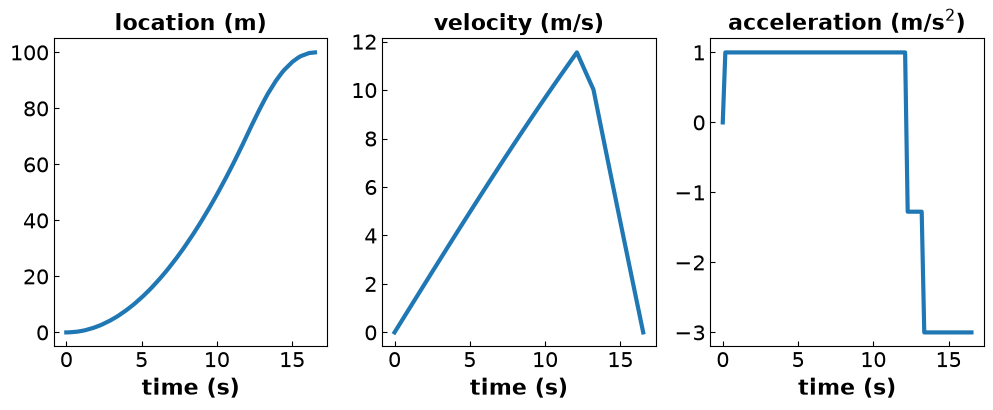

In [6]:
# Define empty lists
x = []  # position, units of length
v = []  # velocity, units of length per time
u = []  # acceleration, units of length per time squared
time = []  # time

# Loop over time and append the solution values for each variable to their respective lists
for i in m.tau:
    time.append(pyo.value(m.time[i]))
    x.append(pyo.value(m.x[i]))
    v.append(pyo.value(m.v[i]))
    u.append(pyo.value(m.u[i]))

# Make a figure
plt.figure(figsize=(12, 4))

# Format subplot 1 (position)
plt.subplot(131)
plt.plot(time, x, linewidth=3, label="x")
plt.title("location (m)", fontsize=16, fontweight="bold")
plt.xlabel("time (s)", fontsize=16, fontweight="bold")
plt.tick_params(direction="in", labelsize=15)

# Format subplot 2 (velocity)
plt.subplot(132)
plt.plot(time, v, linewidth=3, label="v")
plt.xlabel("time (s)", fontsize=16, fontweight="bold")
plt.title("velocity (m/s)", fontsize=16, fontweight="bold")
plt.tick_params(direction="in", labelsize=15)

# Format subplot 3 (acceleration)
plt.subplot(133)
plt.plot(time, u, linewidth=3, label="u")
plt.xlabel("time (s)", fontsize=16, fontweight="bold")
plt.title("acceleration (m/s$^2$)", fontsize=16, fontweight="bold")
plt.tick_params(direction="in", labelsize=15)

plt.show()

**Discussion Questions**

1. How does the time/number of evaluations that IPOPT needs to solve the problem change for a discretized versus non-discretized model?
2. Why might the two solutions differ?
3. Check to make sure that these results make sense. Based on the known derivative relationships between position, velocity, and acceleration, do the 3 plots make sense? Hint: Match up the trends in each graph.